In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
DATASET_PATH = "/content/drive/MyDrive/retinaai-set/dataset"

In [4]:
import os
print(os.listdir(DATASET_PATH))

['diabetic_retinopathy', 'normal', 'glaucoma', 'cataract']


In [5]:
for root, dirs, files in os.walk(DATASET_PATH):
    print("Classes:", dirs)
    break

Classes: ['diabetic_retinopathy', 'normal', 'glaucoma', 'cataract']


In [6]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import ResNet50, EfficientNetB0
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import os

In [7]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

class_names = train_ds.class_names
print("Classes:", class_names)

Found 4218 files belonging to 4 classes.
Using 3375 files for training.
Found 4218 files belonging to 4 classes.
Using 843 files for validation.
Classes: ['cataract', 'diabetic_retinopathy', 'glaucoma', 'normal']


In [8]:
train_ds = train_ds.prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=tf.data.AUTOTUNE)

In [9]:
def build_model():
    base = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(224,224,3))

    for layer in base.layers[:-20]:
        layer.trainable = False

    x = base.output
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.5)(x)

    output = layers.Dense(len(class_names), activation='softmax')(x)

    model = models.Model(inputs=base.input, outputs=output)
    return model

In [10]:
model = build_model()

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [11]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True),
    ModelCheckpoint("best_model.h5", monitor='val_accuracy', save_best_only=True)
]

In [12]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=callbacks
)

Epoch 1/10
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.5409 - loss: 1.2629

106/106 ━━━━━━━━━━━━━━━━━━━━ 884s 8s/step - accuracy: 0.6850 - loss: 0.8620 - val_accuracy: 0.8541 - val_loss: 0.5660
Epoch 2/10
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 246ms/step - accuracy: 0.8431 - loss: 0.4564

106/106 ━━━━━━━━━━━━━━━━━━━━ 32s 306ms/step - accuracy: 0.8516 - loss: 0.4144 - val_accuracy: 0.8992 - val_loss: 0.2995
Epoch 3/10
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 232ms/step - accuracy: 0.8852 - loss: 0.3399

106/106 ━━━━━━━━━━━━━━━━━━━━ 44s 335ms/step - accuracy: 0.8889 - loss: 0.3156 - val_accuracy: 0.9181 - val_loss: 0.2385
Epoch 4/10
106/106 ━━━━━━━━━━━━━━━━━━━━ 36s 338ms/step - accuracy: 0.8942 - loss: 0.2863 - val_accuracy: 0.9170 - val_loss: 0.2274
Epoch 5/10
105/106 ━━━━━━━━━━━━━━━━━━━━ 0s 223ms/step - accuracy: 0.9215 - loss: 0.2248

106/106 ━━━━━━━━━━━━━━━━━━━━ 34s 323ms/step - accuracy: 0.9230 - loss: 0.2191 - val_accuracy: 0.9205 - val_loss: 0.2290
Epoch 6/10
105/106 ━━━━━━━━━━━━━━━━━━━━ 0s 230ms/step - accuracy: 0.9240 - loss: 0.2108

106/106 ━━━━━━━━━━━━━━━━━━━━ 38s 294ms/step - accuracy: 0.9239 - loss: 0.2125 - val_accuracy: 0.9288 - val_loss: 0.2116
Epoch 7/10
105/106 ━━━━━━━━━━━━━━━━━━━━ 0s 240ms/step - accuracy: 0.9237 - loss: 0.1972

106/106 ━━━━━━━━━━━━━━━━━━━━ 41s 297ms/step - accuracy: 0.9253 - loss: 0.2045 - val_accuracy: 0.9312 - val_loss: 0.2071
Epoch 8/10
105/106 ━━━━━━━━━━━━━━━━━━━━ 0s 238ms/step - accuracy: 0.9351 - loss: 0.1732

106/106 ━━━━━━━━━━━━━━━━━━━━ 41s 298ms/step - accuracy: 0.9357 - loss: 0.1716 - val_accuracy: 0.9348 - val_loss: 0.1968
Epoch 9/10
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 225ms/step - accuracy: 0.9447 - loss: 0.1489

106/106 ━━━━━━━━━━━━━━━━━━━━ 40s 291ms/step - accuracy: 0.9499 - loss: 0.1436 - val_accuracy: 0.9383 - val_loss: 0.1955
Epoch 10/10
106/106 ━━━━━━━━━━━━━━━━━━━━ 30s 285ms/step - accuracy: 0.9532 - loss: 0.1373 - val_accuracy: 0.9359 - val_loss: 0.2003


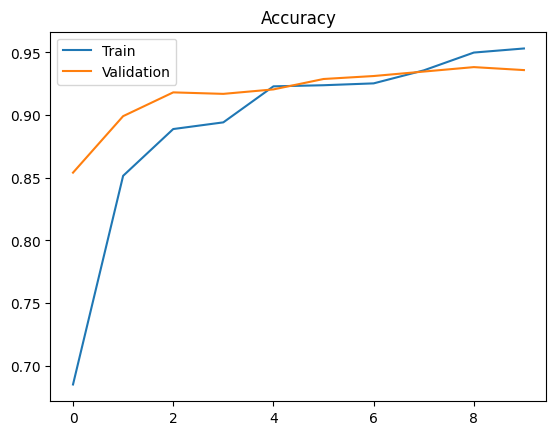

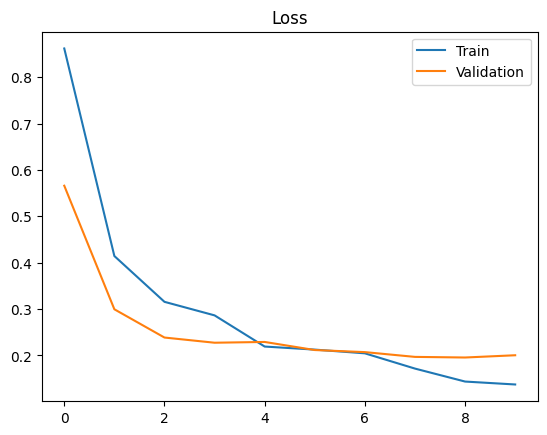

In [13]:
# Accuracy
plt.figure()
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.legend()
plt.title("Accuracy")
plt.show()

# Loss
plt.figure()
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.legend()
plt.title("Loss")
plt.show()

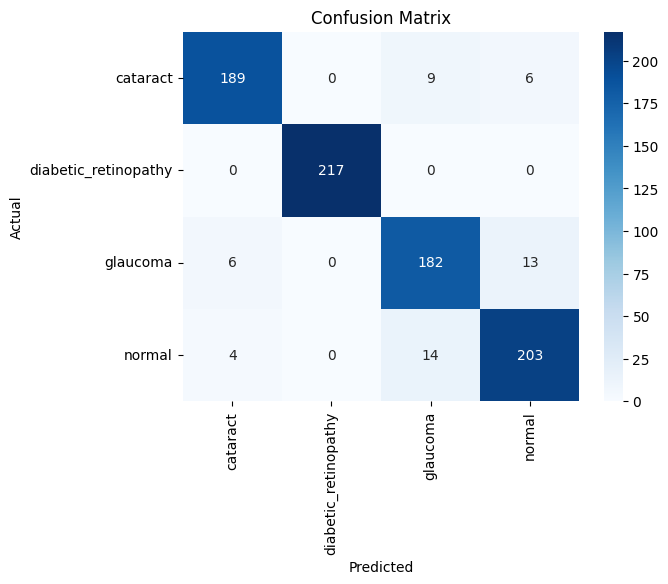

                      precision    recall  f1-score   support

            cataract       0.95      0.93      0.94       204
diabetic_retinopathy       1.00      1.00      1.00       217
            glaucoma       0.89      0.91      0.90       201
              normal       0.91      0.92      0.92       221

            accuracy                           0.94       843
           macro avg       0.94      0.94      0.94       843
        weighted avg       0.94      0.94      0.94       843



In [14]:
y_true = []
y_pred = []

for images, labels in val_ds:
    preds = model.predict(images, verbose=0)
    preds = np.argmax(preds, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(preds)

cm = confusion_matrix(y_true, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

print(classification_report(y_true, y_pred, target_names=class_names))

In [23]:
eff_acc = max(history.history['val_accuracy'])

print("EfficientNet:", eff_acc)


EfficientNet: 0.9383155107498169


In [15]:
model.save("retina_model.h5")

In [16]:
def build_resnet():
    base = ResNet50(weights='imagenet', include_top=False, input_shape=(224,224,3))

    for layer in base.layers[:-20]:
        layer.trainable = False

    x = base.output
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.5)(x)

    output = layers.Dense(len(class_names), activation='softmax')(x)

    model_res = models.Model(inputs=base.input, outputs=output)
    return model_res

In [17]:
model_res = build_resnet()

model_res.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


In [19]:
def get_callbacks(name):
    return [
        EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True),
        ModelCheckpoint(f"{name}_best.h5", monitor='val_accuracy', save_best_only=True)
    ]

In [20]:
history_res = model_res.fit(
    train_ds,
    validation_data=val_ds,
    epochs=12,
    callbacks=get_callbacks("ResNet")
)

Epoch 1/12
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 305ms/step - accuracy: 0.6933 - loss: 0.8077

106/106 ━━━━━━━━━━━━━━━━━━━━ 73s 458ms/step - accuracy: 0.7864 - loss: 0.5741 - val_accuracy: 0.8932 - val_loss: 0.3380
Epoch 2/12
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 246ms/step - accuracy: 0.9076 - loss: 0.2457

106/106 ━━━━━━━━━━━━━━━━━━━━ 33s 310ms/step - accuracy: 0.9123 - loss: 0.2314 - val_accuracy: 0.9134 - val_loss: 0.2338
Epoch 3/12
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 294ms/step - accuracy: 0.9432 - loss: 0.1515

106/106 ━━━━━━━━━━━━━━━━━━━━ 40s 375ms/step - accuracy: 0.9556 - loss: 0.1264 - val_accuracy: 0.9217 - val_loss: 0.2169
Epoch 4/12
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 237ms/step - accuracy: 0.9690 - loss: 0.0869

106/106 ━━━━━━━━━━━━━━━━━━━━ 32s 303ms/step - accuracy: 0.9778 - loss: 0.0695 - val_accuracy: 0.9229 - val_loss: 0.2413
Epoch 5/12
106/106 ━━━━━━━━━━━━━━━━━━━━ 40s 293ms/step - accuracy: 0.9790 - loss: 0.0655 - val_accuracy: 0.9146 - val_loss: 0.2768
Epoch 6/12
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 234ms/step - accuracy: 0.9859 - loss: 0.0419

106/106 ━━━━━━━━━━━━━━━━━━━━ 32s 303ms/step - accuracy: 0.9867 - loss: 0.0393 - val_accuracy: 0.9300 - val_loss: 0.2549


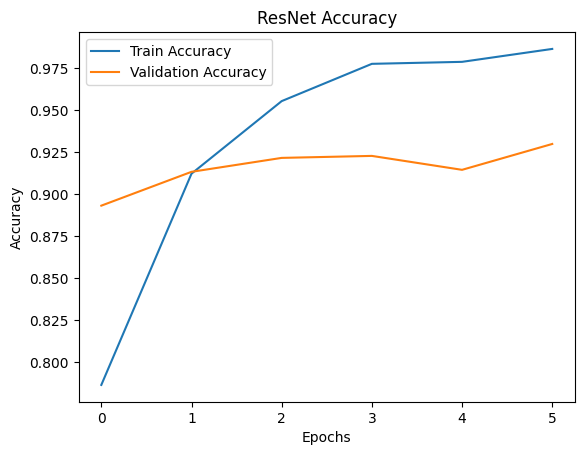

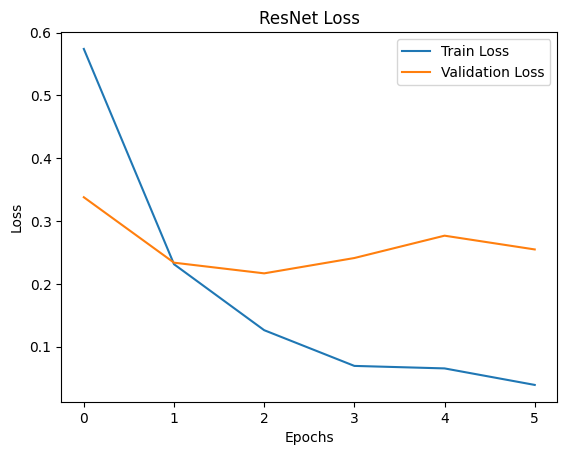

In [26]:
# Accuracy Graph
plt.figure()
plt.plot(history_res.history['accuracy'], label='Train Accuracy')
plt.plot(history_res.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title("ResNet Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.show()

# Loss Graph
plt.figure()
plt.plot(history_res.history['loss'], label='Train Loss')
plt.plot(history_res.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("ResNet Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()

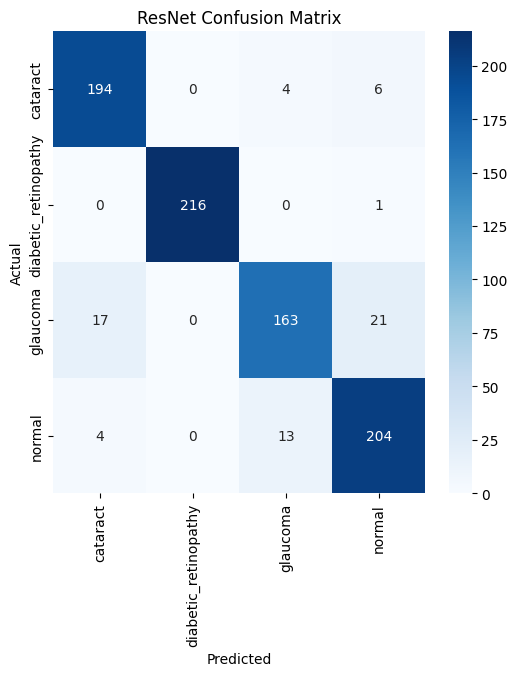


ResNet Classification Report:

                      precision    recall  f1-score   support

            cataract       0.90      0.95      0.93       204
diabetic_retinopathy       1.00      1.00      1.00       217
            glaucoma       0.91      0.81      0.86       201
              normal       0.88      0.92      0.90       221

            accuracy                           0.92       843
           macro avg       0.92      0.92      0.92       843
        weighted avg       0.92      0.92      0.92       843



In [27]:
y_true = []
y_pred = []

for images, labels in val_ds:
    preds = model_res.predict(images, verbose=0)
    preds = np.argmax(preds, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(preds)

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("ResNet Confusion Matrix")
plt.show()

print("\nResNet Classification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_names))

In [28]:
res_acc = max(history_res.history['val_accuracy'])
print("ResNet Accuracy:", res_acc)

ResNet Accuracy: 0.9300118684768677


In [29]:
def build_cnn():
    model_cnn = models.Sequential([
        layers.Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
        layers.MaxPooling2D(),

        layers.Conv2D(64, (3,3), activation='relu'),
        layers.MaxPooling2D(),

        layers.Conv2D(128, (3,3), activation='relu'),
        layers.MaxPooling2D(),

        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.5),

        layers.Dense(len(class_names), activation='softmax')
    ])
    return model_cnn

In [30]:
model_cnn = build_cnn()

model_cnn.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [31]:
history_cnn = model_cnn.fit(
    train_ds,
    validation_data=val_ds,
    epochs=12,
    callbacks=get_callbacks("CNN")
)

Epoch 1/12
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 286ms/step - accuracy: 0.5069 - loss: 36.8758

106/106 ━━━━━━━━━━━━━━━━━━━━ 50s 390ms/step - accuracy: 0.5947 - loss: 9.8015 - val_accuracy: 0.7319 - val_loss: 0.6873
Epoch 2/12
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 242ms/step - accuracy: 0.6361 - loss: 0.7430

106/106 ━━━━━━━━━━━━━━━━━━━━ 32s 300ms/step - accuracy: 0.6708 - loss: 0.6944 - val_accuracy: 0.7485 - val_loss: 0.5928
Epoch 3/12
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 244ms/step - accuracy: 0.6952 - loss: 0.6395

106/106 ━━━━━━━━━━━━━━━━━━━━ 32s 301ms/step - accuracy: 0.7061 - loss: 0.6270 - val_accuracy: 0.7592 - val_loss: 0.5630
Epoch 4/12
105/106 ━━━━━━━━━━━━━━━━━━━━ 0s 242ms/step - accuracy: 0.7204 - loss: 0.6093

106/106 ━━━━━━━━━━━━━━━━━━━━ 33s 308ms/step - accuracy: 0.7280 - loss: 0.5998 - val_accuracy: 0.7639 - val_loss: 0.5709
Epoch 5/12
106/106 ━━━━━━━━━━━━━━━━━━━━ 34s 319ms/step - accuracy: 0.7319 - loss: 0.5955 - val_accuracy: 0.7497 - val_loss: 0.5713
Epoch 6/12
105/106 ━━━━━━━━━━━━━━━━━━━━ 0s 238ms/step - accuracy: 0.7246 - loss: 0.5748

106/106 ━━━━━━━━━━━━━━━━━━━━ 38s 294ms/step - accuracy: 0.7357 - loss: 0.5701 - val_accuracy: 0.7758 - val_loss: 0.5369
Epoch 7/12
106/106 ━━━━━━━━━━━━━━━━━━━━ 42s 307ms/step - accuracy: 0.7431 - loss: 0.5514 - val_accuracy: 0.7722 - val_loss: 0.5366
Epoch 8/12
106/106 ━━━━━━━━━━━━━━━━━━━━ 35s 332ms/step - accuracy: 0.7553 - loss: 0.5546 - val_accuracy: 0.7639 - val_loss: 0.5530
Epoch 9/12
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 218ms/step - accuracy: 0.7451 - loss: 0.5526

106/106 ━━━━━━━━━━━━━━━━━━━━ 31s 292ms/step - accuracy: 0.7511 - loss: 0.5415 - val_accuracy: 0.7770 - val_loss: 0.5520
Epoch 10/12
105/106 ━━━━━━━━━━━━━━━━━━━━ 0s 224ms/step - accuracy: 0.7608 - loss: 0.5447

106/106 ━━━━━━━━━━━━━━━━━━━━ 45s 326ms/step - accuracy: 0.7713 - loss: 0.5305 - val_accuracy: 0.7805 - val_loss: 0.5278
Epoch 11/12
106/106 ━━━━━━━━━━━━━━━━━━━━ 31s 288ms/step - accuracy: 0.7801 - loss: 0.5033 - val_accuracy: 0.7758 - val_loss: 0.5857
Epoch 12/12
106/106 ━━━━━━━━━━━━━━━━━━━━ 31s 291ms/step - accuracy: 0.7760 - loss: 0.4988 - val_accuracy: 0.7770 - val_loss: 0.5468


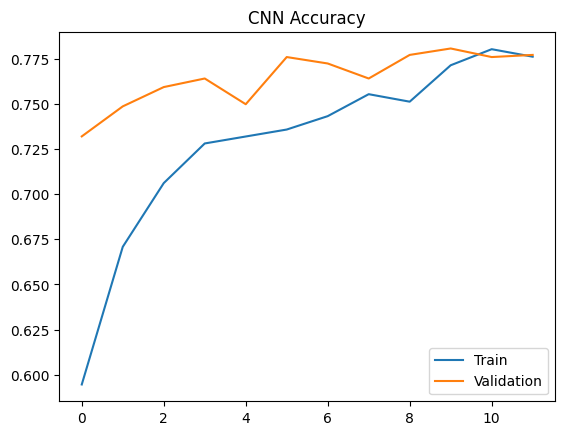

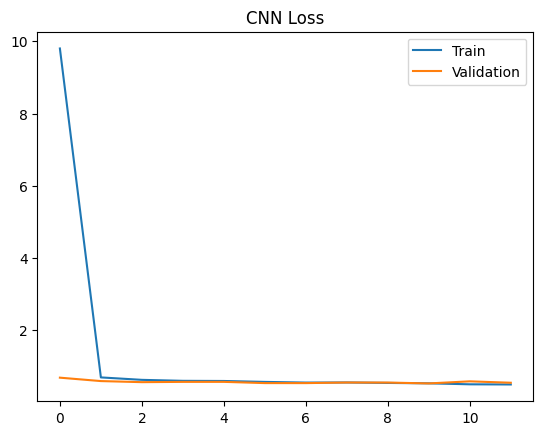

In [32]:
plt.figure()
plt.plot(history_cnn.history['accuracy'], label='Train')
plt.plot(history_cnn.history['val_accuracy'], label='Validation')
plt.legend()
plt.title("CNN Accuracy")
plt.show()

plt.figure()
plt.plot(history_cnn.history['loss'], label='Train')
plt.plot(history_cnn.history['val_loss'], label='Validation')
plt.legend()
plt.title("CNN Loss")
plt.show()

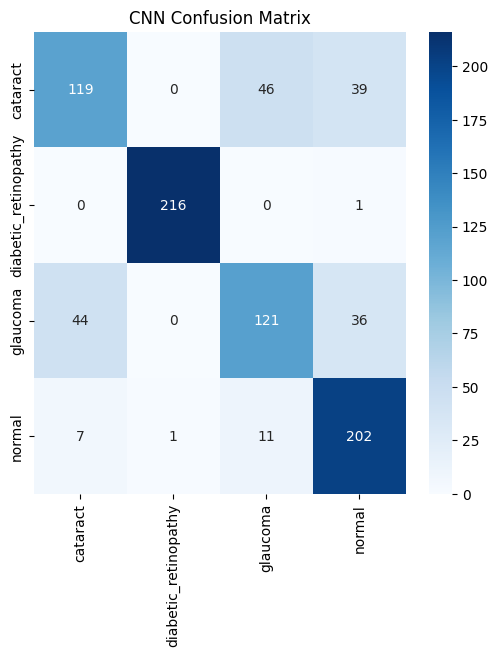

                      precision    recall  f1-score   support

            cataract       0.70      0.58      0.64       204
diabetic_retinopathy       1.00      1.00      1.00       217
            glaucoma       0.68      0.60      0.64       201
              normal       0.73      0.91      0.81       221

            accuracy                           0.78       843
           macro avg       0.78      0.77      0.77       843
        weighted avg       0.78      0.78      0.77       843



In [33]:
y_true = []
y_pred = []

for images, labels in val_ds:
    preds = model_cnn.predict(images, verbose=0)
    preds = np.argmax(preds, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(preds)

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.title("CNN Confusion Matrix")
plt.show()

print(classification_report(y_true, y_pred, target_names=class_names))

In [34]:
cnn_acc = max(history_cnn.history['val_accuracy'])
print("CNN Accuracy:", cnn_acc)

CNN Accuracy: 0.7805456519126892


In [47]:
model_cnn.save("cnn_model.h5")

In [48]:
def build_vit():
    inputs = tf.keras.Input(shape=(224, 224, 3))

    # Patch Embedding
    x = layers.Conv2D(64, kernel_size=16, strides=16, padding='valid')(inputs)
    x = layers.Reshape((-1, 64))(x)

    # Transformer Encoder
    for _ in range(4):
        x1 = layers.LayerNormalization()(x)

        attention = layers.MultiHeadAttention(num_heads=4, key_dim=64)(x1, x1)
        x2 = layers.Add()([x, attention])

        x3 = layers.LayerNormalization()(x2)
        x3 = layers.Dense(128, activation='relu')(x3)
        x3 = layers.Dense(64)(x3)

        x = layers.Add()([x2, x3])

    # Classification Head
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.5)(x)

    outputs = layers.Dense(len(class_names), activation='softmax')(x)

    model = tf.keras.Model(inputs, outputs)
    return model

In [49]:
model_vit = build_vit()

model_vit.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [50]:
history_vit = model_vit.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=get_callbacks("ViT")
)

Epoch 1/10
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 296ms/step - accuracy: 0.2727 - loss: 7.3006

106/106 ━━━━━━━━━━━━━━━━━━━━ 62s 396ms/step - accuracy: 0.2841 - loss: 4.1745 - val_accuracy: 0.3677 - val_loss: 1.3003
Epoch 2/10
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 230ms/step - accuracy: 0.3519 - loss: 1.4589

106/106 ━━━━━━━━━━━━━━━━━━━━ 31s 294ms/step - accuracy: 0.3336 - loss: 1.4303 - val_accuracy: 0.3843 - val_loss: 1.3337
Epoch 3/10
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 240ms/step - accuracy: 0.3427 - loss: 1.3715

106/106 ━━━━━━━━━━━━━━━━━━━━ 31s 296ms/step - accuracy: 0.3378 - loss: 1.3726 - val_accuracy: 0.4199 - val_loss: 1.2870
Epoch 4/10
106/106 ━━━━━━━━━━━━━━━━━━━━ 43s 321ms/step - accuracy: 0.3150 - loss: 1.3597 - val_accuracy: 0.3677 - val_loss: 1.3025
Epoch 5/10
106/106 ━━━━━━━━━━━━━━━━━━━━ 38s 289ms/step - accuracy: 0.2951 - loss: 1.3623 - val_accuracy: 0.3096 - val_loss: 1.3490
Epoch 6/10
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 217ms/step - accuracy: 0.3198 - loss: 1.3730

106/106 ━━━━━━━━━━━━━━━━━━━━ 41s 289ms/step - accuracy: 0.3233 - loss: 1.3637 - val_accuracy: 0.4448 - val_loss: 1.2671
Epoch 7/10
106/106 ━━━━━━━━━━━━━━━━━━━━ 33s 316ms/step - accuracy: 0.3327 - loss: 1.3515 - val_accuracy: 0.4270 - val_loss: 1.2724
Epoch 8/10
106/106 ━━━━━━━━━━━━━━━━━━━━ 34s 321ms/step - accuracy: 0.2996 - loss: 1.3588 - val_accuracy: 0.4140 - val_loss: 1.2872
Epoch 9/10
106/106 ━━━━━━━━━━━━━━━━━━━━ 30s 286ms/step - accuracy: 0.2924 - loss: 1.3625 - val_accuracy: 0.3784 - val_loss: 1.3024


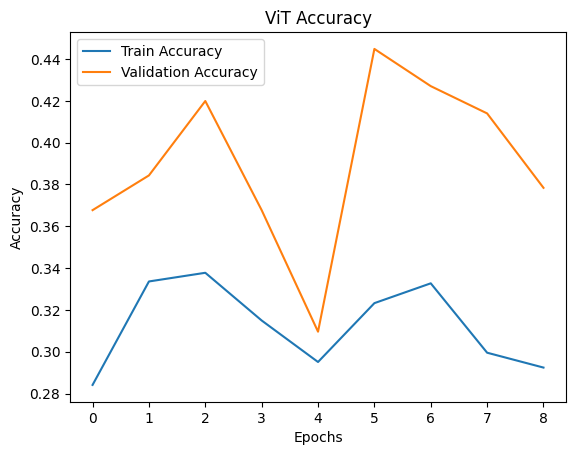

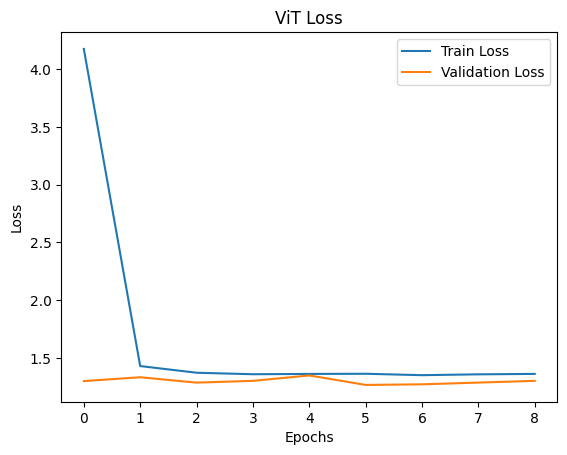

In [51]:
# Accuracy
plt.figure()
plt.plot(history_vit.history['accuracy'], label='Train Accuracy')
plt.plot(history_vit.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title("ViT Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.show()

# Loss
plt.figure()
plt.plot(history_vit.history['loss'], label='Train Loss')
plt.plot(history_vit.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("ViT Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()

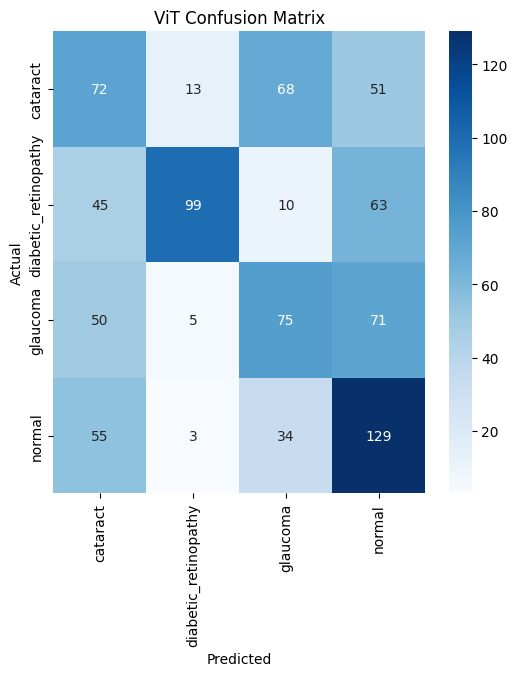


ViT Classification Report:

                      precision    recall  f1-score   support

            cataract       0.32      0.35      0.34       204
diabetic_retinopathy       0.82      0.46      0.59       217
            glaucoma       0.40      0.37      0.39       201
              normal       0.41      0.58      0.48       221

            accuracy                           0.44       843
           macro avg       0.49      0.44      0.45       843
        weighted avg       0.49      0.44      0.45       843



In [52]:
y_true = []
y_pred = []

for images, labels in val_ds:
    preds = model_vit.predict(images, verbose=0)
    preds = np.argmax(preds, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(preds)

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("ViT Confusion Matrix")
plt.show()

print("\nViT Classification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_names))

In [53]:
vit_acc = max(history_vit.history['val_accuracy'])
print("ViT Final Accuracy:", vit_acc)

ViT Final Accuracy: 0.44483986496925354


In [54]:
results = {
    "CNN": cnn_acc,
    "ResNet": res_acc,
    "EfficientNet": eff_acc,
    "ViT": vit_acc
}

print("\n===== MODEL ACCURACY COMPARISON =====")
for model, acc in results.items():
    print(f"{model}: {acc:.4f}")

best_model = max(results, key=results.get)
print("\nBest Model:", best_model)


===== MODEL ACCURACY COMPARISON =====
CNN: 0.7805
ResNet: 0.9300
EfficientNet: 0.9383
ViT: 0.4448

Best Model: EfficientNet


In [61]:
model_res.save("best_model.h5")

In [69]:
!pip install gradio

In [70]:
import gradio as gr
from tensorflow.keras.preprocessing import image
import numpy as np

def predict(img):
    img = img.resize((224,224))
    img_array = np.array(img)
    img_array = np.expand_dims(img_array, axis=0)

    preds = model_res.predict(img_array)   # or best model
    predicted_class = class_names[np.argmax(preds)]
    confidence = np.max(preds)

    return f"Prediction: {predicted_class} | Confidence: {confidence:.2f}"

In [71]:
interface = gr.Interface(
    fn=predict,
    inputs=gr.Image(type="pil"),
    outputs="text",
    title="RETINAAI - Retinal Disease Detection",
    description="Upload a retinal image to detect disease"
)

In [72]:
interface.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://e3e172f7535ae1de86.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [73]:
model_res.save("/content/drive/MyDrive/final_model.h5")